# 1. Imports, configuration, load, and validation

In [3]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "Data"
PROCESSED_DATA_DIR = DATA_DIR / "Processed"

INPUT_FILE = (
    PROCESSED_DATA_DIR
    / "engineered_air_quality.parquet"
)

ENCODER_LENGTH = 168
PREDICTION_LENGTH = 15
REQUIRED_SEQUENCE_LENGTH = (
    ENCODER_LENGTH + PREDICTION_LENGTH
)

POLLUTANT_COLUMNS = [
    "pm2_5",
    "pm10",
    "no",
    "no2",
    "nox",
    "nh3",
    "co",
    "so2",
    "o3",
]

WEATHER_COLUMNS = [
    "ambient_temperature",
    "relative_humidity",
    "solar_radiation",
    "rainfall",
]

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Engineered dataset not found: {INPUT_FILE}\n"
        "Run 03_feature_engineering.ipynb first."
    )

df = pd.read_parquet(
    INPUT_FILE,
    engine="pyarrow",
)

available_pollutants = [
    col
    for col in POLLUTANT_COLUMNS
    if col in df.columns
]

available_weather_columns = [
    col
    for col in WEATHER_COLUMNS
    if col in df.columns
]

required_columns = [
    "timestamp",
    "state",
    "city",
    "station_id",
    "time_idx",
    "sequence_segment_id",
]

missing_required_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_required_columns:
    raise ValueError(
        "Missing required engineered columns: "
        f"{missing_required_columns}"
    )

if not available_pollutants:
    raise ValueError(
        "No pollutant target columns are available."
    )

memory_gb = (
    df.memory_usage(deep=True).sum()
    / 1024**3
)

print("EDA dataset loaded successfully.")
print(f"Shape: {df.shape}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory usage: {memory_gb:,.3f} GB")

print(
    f"\nTime range: "
    f"{df['timestamp'].min()} "
    f"to {df['timestamp'].max()}"
)

print(
    f"Stations: "
    f"{df['station_id'].nunique():,}"
)

print(
    f"States: "
    f"{df['state'].nunique():,}"
)

print(
    f"Cities: "
    f"{df['city'].nunique():,}"
)

print(
    "\nAvailable pollutants:"
)
print(available_pollutants)

print(
    "\nAvailable weather columns:"
)
print(available_weather_columns)

display(df.head())

Matplotlib is building the font cache; this may take a moment.


EDA dataset loaded successfully.
Shape: (3429120, 38)
Rows: 3,429,120
Columns: 38
Memory usage: 0.402 GB

Time range: 2017-01-01 00:00:00 to 2026-06-30 23:00:00
Stations: 66
States: 19
Cities: 66

Available pollutants:
['pm2_5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3']

Available weather columns:
['ambient_temperature', 'relative_humidity', 'solar_radiation', 'rainfall']


,state,city,latitude,longitude,timestamp,pm2_5,pm10,no,no2,nox,nh3,so2,co,o3,ambient_temperature,relative_humidity,solar_radiation,rainfall,station_id,time_idx,hours_since_previous,has_time_gap,year,month,day,hour,day_of_week,day_of_year,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,sequence_segment_id
0,Andhra Pradesh,"Anand Kala Kshetram, Rajamahendravaram (, )",16.9873,81.7363,2017-09-05 11:00:00,25.0000,45.0000,1.8000,12.2000,7.9000,10.2000,5.6000,0.1000,79.5000,33.8000,69.0000,372.0000,0.0000,0,5939,NaN,0,2017,9,5,11,1,248,0,0.2588,-0.9659,0.7818,0.6235,-0.8660,-0.5000,-0.8945,-0.4470,1
1,Andhra Pradesh,"Anand Kala Kshetram, Rajamahendravaram (, )",16.9873,81.7363,2017-09-05 12:00:00,25.0000,45.0000,1.8000,12.2000,7.9000,10.2000,5.6000,0.1000,79.5000,33.8000,69.0000,372.0000,0.0000,0,5940,1.0000,0,2017,9,5,12,1,248,0,-0.0000,-1.0000,0.7818,0.6235,-0.8660,-0.5000,-0.8945,-0.4470,1
2,Andhra Pradesh,"Anand Kala Kshetram, Rajamahendravaram (, )",16.9873,81.7363,2017-09-05 13:00:00,25.0000,45.0000,1.8000,12.2000,7.9000,10.2000,5.6000,0.1000,79.5000,33.8000,69.0000,372.0000,0.0000,0,5941,1.0000,0,2017,9,5,13,1,248,0,-0.2588,-0.9659,0.7818,0.6235,-0.8660,-0.5000,-0.8945,-0.4470,1
3,Andhra Pradesh,"Anand Kala Kshetram, Rajamahendravaram (, )",16.9873,81.7363,2017-09-05 14:00:00,25.0000,45.0000,1.8000,12.2000,7.9000,10.2000,5.6000,0.1000,79.5000,33.8000,69.0000,372.0000,0.0000,0,5942,1.0000,0,2017,9,5,14,1,248,0,-0.5000,-0.8660,0.7818,0.6235,-0.8660,-0.5000,-0.8945,-0.4470,1
4,Andhra Pradesh,"Anand Kala Kshetram, Rajamahendravaram (, )",16.9873,81.7363,2017-09-05 15:00:00,23.0000,49.5000,0.6500,14.5500,8.2800,8.8500,4.5200,0.1500,62.5000,32.2200,70.5000,290.7500,0.0000,0,5943,1.0000,0,2017,9,5,15,1,248,0,-0.7071,-0.7071,0.7818,0.6235,-0.8660,-0.5000,-0.8945,-0.4470,1


# 2. Data quality, missing values, infinities and distribution

DATA QUALITY SUMMARY


,missing_count,missing_percent,infinite_count
ambient_temperature,10,0.0003,0
pm2_5,0,0.0000,0
pm10,0,0.0000,0
no,0,0.0000,0
no2,0,0.0000,0
nox,0,0.0000,0
nh3,0,0.0000,0
co,0,0.0000,0
so2,0,0.0000,0
o3,0,0.0000,0



POLLUTANT DESCRIPTIVE STATISTICS


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
pm2_5,"3,429,120.0000",53.9065,60.3510,0.0000,2.7500,8.0000,21.0000,36.1650,64.2500,156.6500,301.0000,999.9900
pm10,"3,429,120.0000",114.7141,106.5047,0.0000,9.5200,21.4000,48.6875,82.7500,142.0700,318.0000,548.5000,"1,000.0000"
no,"3,429,120.0000",13.6204,30.1823,0.0000,0.2000,0.9325,2.7800,6.0000,12.3250,50.1800,142.8500,500.0000
no2,"3,429,120.0000",24.4239,27.2925,0.0000,0.3750,2.5700,8.8600,16.3700,29.1600,73.9400,134.1800,499.9900
nox,"3,429,120.0000",28.2030,36.7818,0.0000,0.0000,3.2400,10.4000,19.0000,32.6500,82.4800,189.4000,500.0000
nh3,"3,429,120.0000",21.1689,22.2068,0.0000,0.4711,2.5900,8.5000,15.9913,25.6300,56.2500,100.7000,499.9900
co,"3,429,120.0000",0.8327,0.8408,0.0000,0.0000,0.0000,0.3600,0.6400,1.0150,2.2200,4.2500,41.6700
so2,"3,429,120.0000",13.0567,15.7275,0.0000,0.2800,1.4009,4.8500,8.8200,15.5000,37.1250,80.4000,200.0000
o3,"3,429,120.0000",27.6380,27.4580,0.0000,0.4500,1.9400,9.5900,19.2900,35.9100,84.2000,131.8500,932.0000


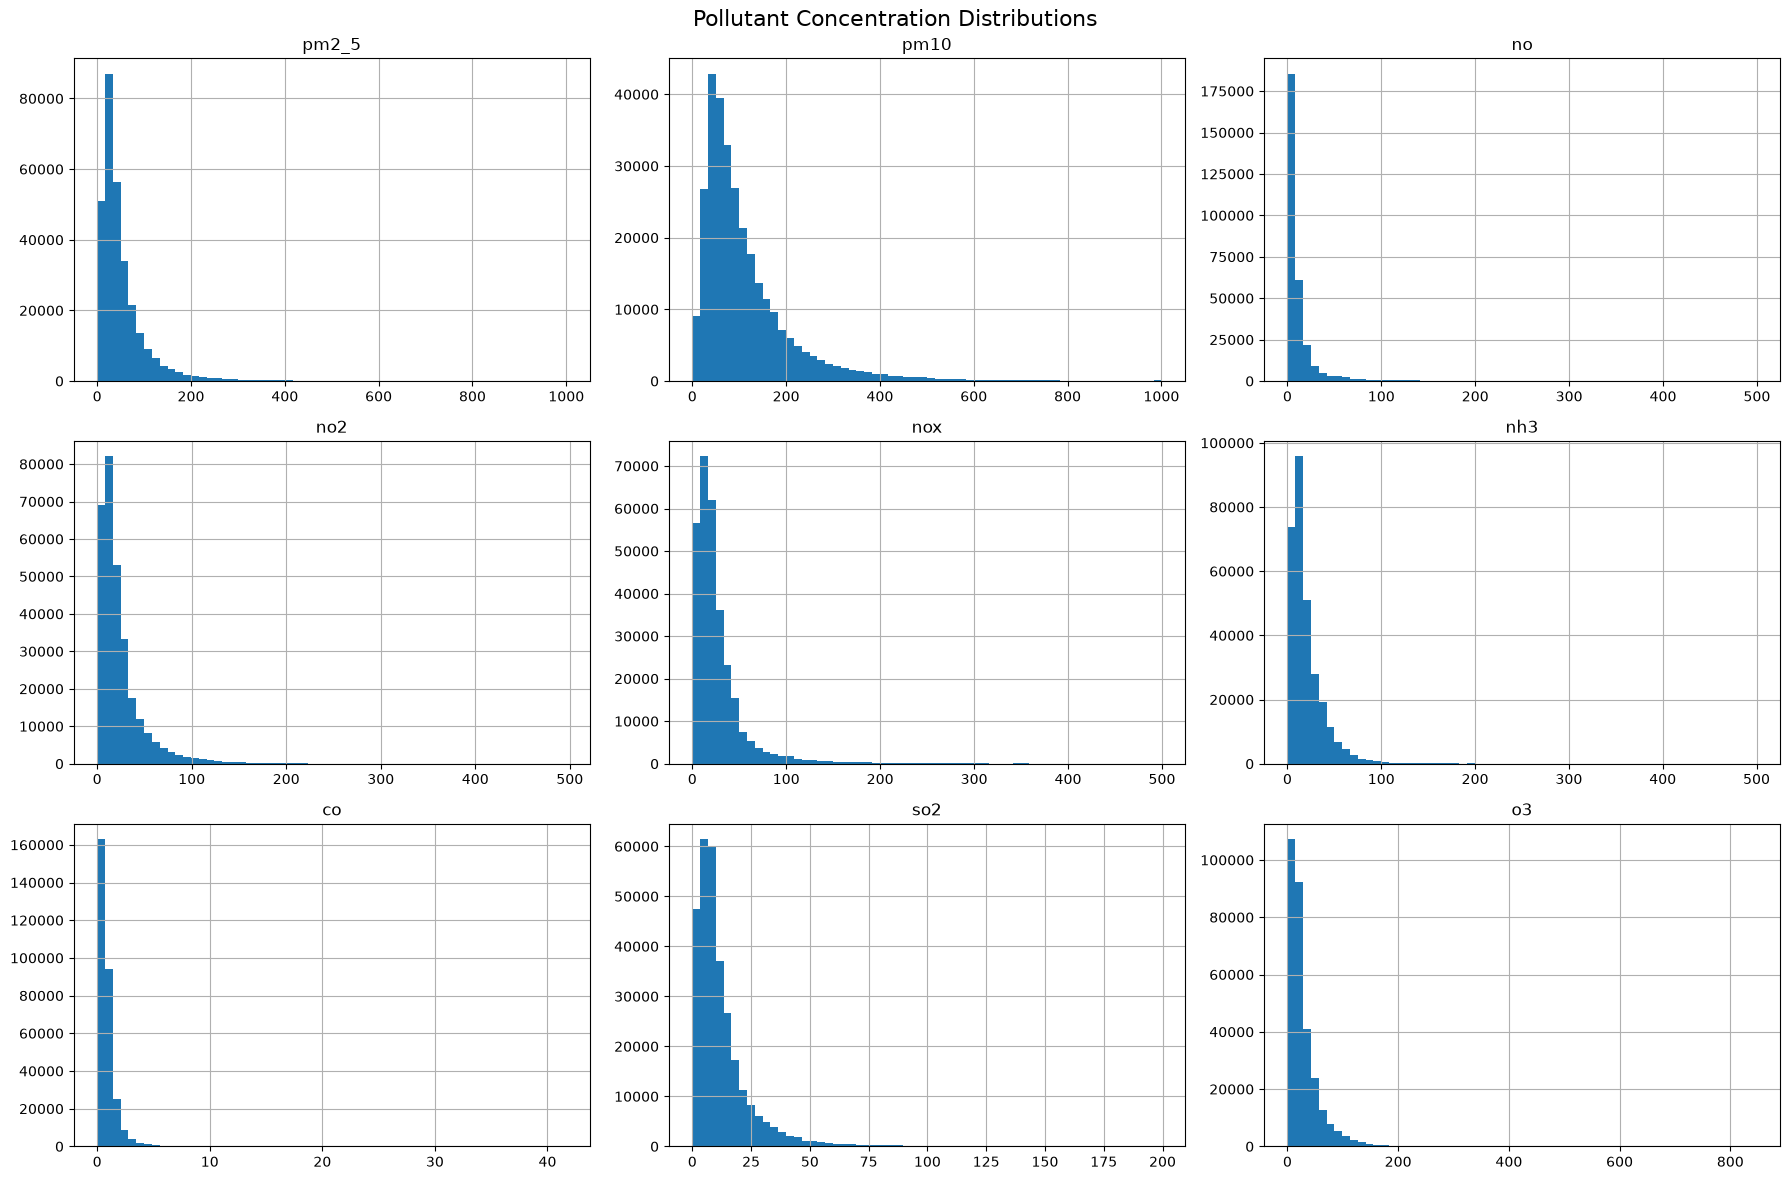

57126

In [4]:
numeric_analysis_columns = (
    available_pollutants
    + available_weather_columns
)

missing_summary = (
    df[numeric_analysis_columns]
    .isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"]
    .div(len(df))
    .mul(100)
)

infinite_counts = pd.Series(
    {
        col: int(
            np.isinf(
                df[col]
                .to_numpy(
                    dtype=np.float64,
                    na_value=np.nan,
                )
            ).sum()
        )
        for col in numeric_analysis_columns
    },
    name="infinite_count",
)

quality_summary = missing_summary.join(
    infinite_counts
)

quality_summary = quality_summary.sort_values(
    "missing_percent",
    ascending=False,
)

print("DATA QUALITY SUMMARY")
display(quality_summary)

print("\nPOLLUTANT DESCRIPTIVE STATISTICS")

pollutant_statistics = (
    df[available_pollutants]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
)

display(pollutant_statistics)

plot_sample_size = min(
    300_000,
    len(df),
)

plot_df = df[
    numeric_analysis_columns
].sample(
    n=plot_sample_size,
    random_state=42,
)

plot_df[available_pollutants].hist(
    bins=60,
    figsize=(18, 12),
)

plt.suptitle(
    "Pollutant Concentration Distributions",
    fontsize=16,
)

plt.tight_layout()
plt.show()

del missing_summary
del infinite_counts

gc.collect()

# 3. Temporal, geographic and station coverage analsis

STATION COVERAGE SUMMARY


,observations,start_time,end_time,segments,coverage_days
count,66.0000,66,66,66.0000,66.0000
mean,"51,956.3636",2019-11-15 17:21:49.090908928,2026-04-25 09:23:38.181818112,134.9848,"2,352.6679"
min,"23,991.0000",2017-01-01 00:00:00,2023-03-15 17:00:00,11.0000,"1,148.3750"
5%,"27,163.7500",2017-01-18 07:30:00,2025-12-31 16:15:00,24.7500,"1,218.1979"
25%,"37,345.7500",2018-06-09 19:00:00,2026-06-30 23:00:00,55.0000,"1,715.0833"
50%,"52,225.0000",2019-09-17 07:00:00,2026-06-30 23:00:00,86.0000,"2,428.2083"
75%,"67,853.5000",2021-07-17 11:30:00,2026-06-30 23:00:00,165.7500,"2,911.4375"
95%,"75,817.0000",2022-09-27 00:45:00,2026-06-30 23:00:00,449.7500,"3,450.6458"
max,"79,744.0000",2022-10-21 13:00:00,2026-06-30 23:00:00,867.0000,"3,467.9583"
std,"16,460.7864",NaN,NaN,147.2947,702.0306



STATE COVERAGE


,observations,stations,cities,start_time,end_time
state,,,,,
Delhi,355486,5,5,2017-01-01 00:00:00,2026-06-30 23:00:00
Gujarat,280042,5,5,2017-01-01 00:00:00,2026-06-30 23:00:00
Karnataka,273727,5,5,2017-01-01 17:00:00,2026-06-30 23:00:00
Haryana,267875,5,5,2019-01-04 09:00:00,2026-06-30 23:00:00
West Bengal,262816,4,4,2018-01-31 21:00:00,2026-06-30 23:00:00
Madhya Pradesh,261154,5,5,2018-12-11 20:00:00,2026-06-30 23:00:00
Andhra Pradesh,256378,4,4,2017-07-01 00:00:00,2026-06-30 23:00:00
Maharashtra,229190,4,4,2017-01-04 10:00:00,2026-06-30 23:00:00
Punjab,221669,3,3,2017-03-01 00:00:00,2026-06-30 23:00:00


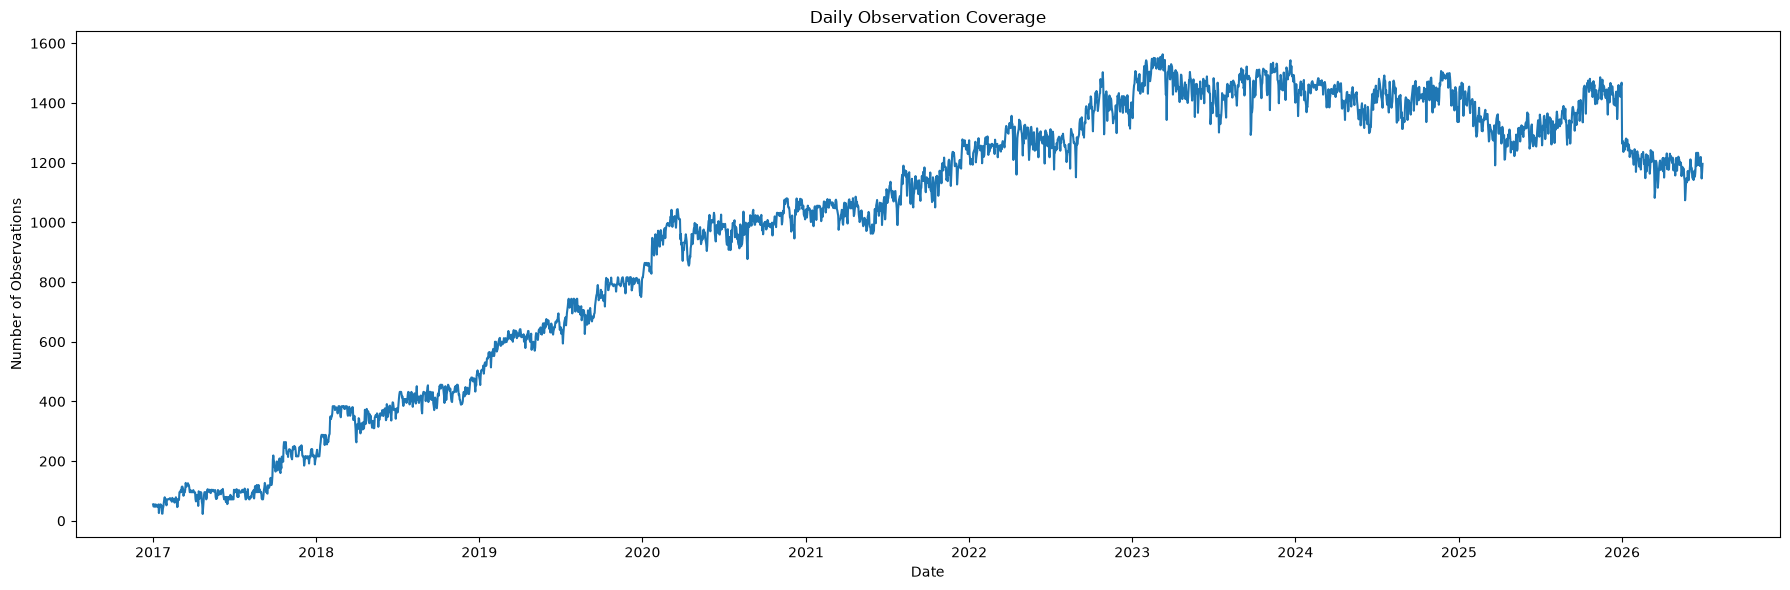

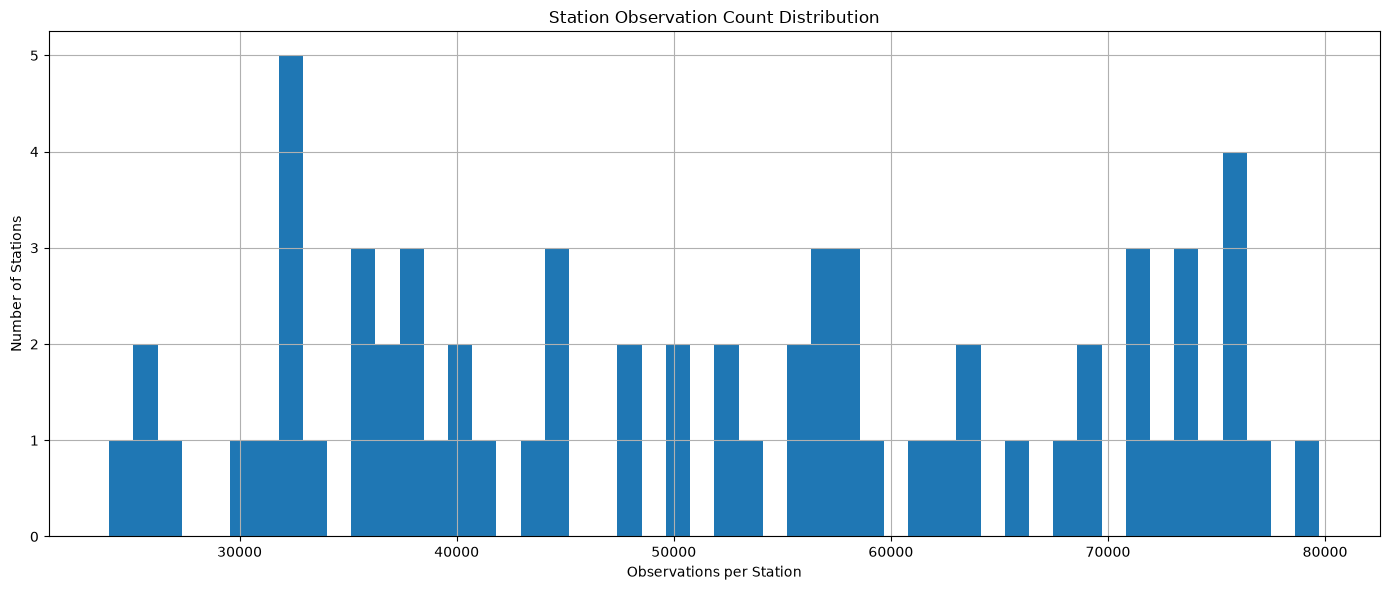

4426

In [5]:
station_coverage = (
    df.groupby(
        "station_id",
        observed=True,
    )
    .agg(
        observations=("timestamp", "size"),
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        segments=(
            "sequence_segment_id",
            "nunique",
        ),
    )
)

station_coverage["coverage_days"] = (
    station_coverage["end_time"]
    - station_coverage["start_time"]
).dt.total_seconds().div(
    86400
)

print("STATION COVERAGE SUMMARY")

display(
    station_coverage.describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ]
    )
)

state_summary = (
    df.groupby(
        "state",
        observed=True,
    )
    .agg(
        observations=("timestamp", "size"),
        stations=("station_id", "nunique"),
        cities=("city", "nunique"),
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
    )
    .sort_values(
        "observations",
        ascending=False,
    )
)

print("\nSTATE COVERAGE")

display(state_summary)

hourly_observations = (
    df.set_index("timestamp")
    .resample("D")
    .size()
)

fig, ax = plt.subplots(
    figsize=(18, 6)
)

ax.plot(
    hourly_observations.index,
    hourly_observations.values,
)

ax.set_title(
    "Daily Observation Coverage"
)

ax.set_xlabel("Date")
ax.set_ylabel("Number of Observations")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(
    figsize=(14, 6)
)

station_coverage["observations"].hist(
    bins=50,
    ax=ax,
)

ax.set_title(
    "Station Observation Count Distribution"
)

ax.set_xlabel(
    "Observations per Station"
)

ax.set_ylabel("Number of Stations")

plt.tight_layout()
plt.show()

gc.collect()

# 4. Pollutant correlation and temporal patterns

POLLUTANT AND WEATHER CORRELATION


,pm2_5,pm10,no,no2,nox,nh3,co,so2,o3,ambient_temperature,relative_humidity,solar_radiation,rainfall
pm2_5,1.0000,0.8060,0.3370,0.3600,0.3840,0.2800,0.3490,0.0990,-0.0120,-0.3130,-0.0330,-0.0650,-0.0120
pm10,0.8060,1.0000,0.3780,0.4150,0.4360,0.2900,0.3730,0.1300,0.0140,-0.2310,-0.1260,-0.0530,-0.0010
no,0.3370,0.3780,1.0000,0.4580,0.8680,0.2480,0.3820,0.0940,-0.1000,-0.1360,0.0220,-0.0410,-0.0040
no2,0.3600,0.4150,0.4580,1.0000,0.7120,0.3430,0.3240,0.1810,0.0040,-0.1510,-0.1050,-0.0590,0.0130
nox,0.3840,0.4360,0.8680,0.7120,1.0000,0.3180,0.4020,0.1270,-0.0810,-0.1680,-0.0200,-0.0420,-0.0010
nh3,0.2800,0.2900,0.2480,0.3430,0.3180,1.0000,0.1440,0.0320,0.0330,-0.1010,-0.0330,-0.0250,0.0230
co,0.3490,0.3730,0.3820,0.3240,0.4020,0.1440,1.0000,0.0960,-0.0690,-0.1340,-0.0090,-0.0570,0.0050
so2,0.0990,0.1300,0.0940,0.1810,0.1270,0.0320,0.0960,1.0000,0.0690,0.0040,-0.1300,-0.0140,-0.0070
o3,-0.0120,0.0140,-0.1000,0.0040,-0.0810,0.0330,-0.0690,0.0690,1.0000,0.1950,-0.3220,0.2310,0.0040
ambient_temperature,-0.3130,-0.2310,-0.1360,-0.1510,-0.1680,-0.1010,-0.1340,0.0040,0.1950,1.0000,-0.3110,0.2100,0.0080


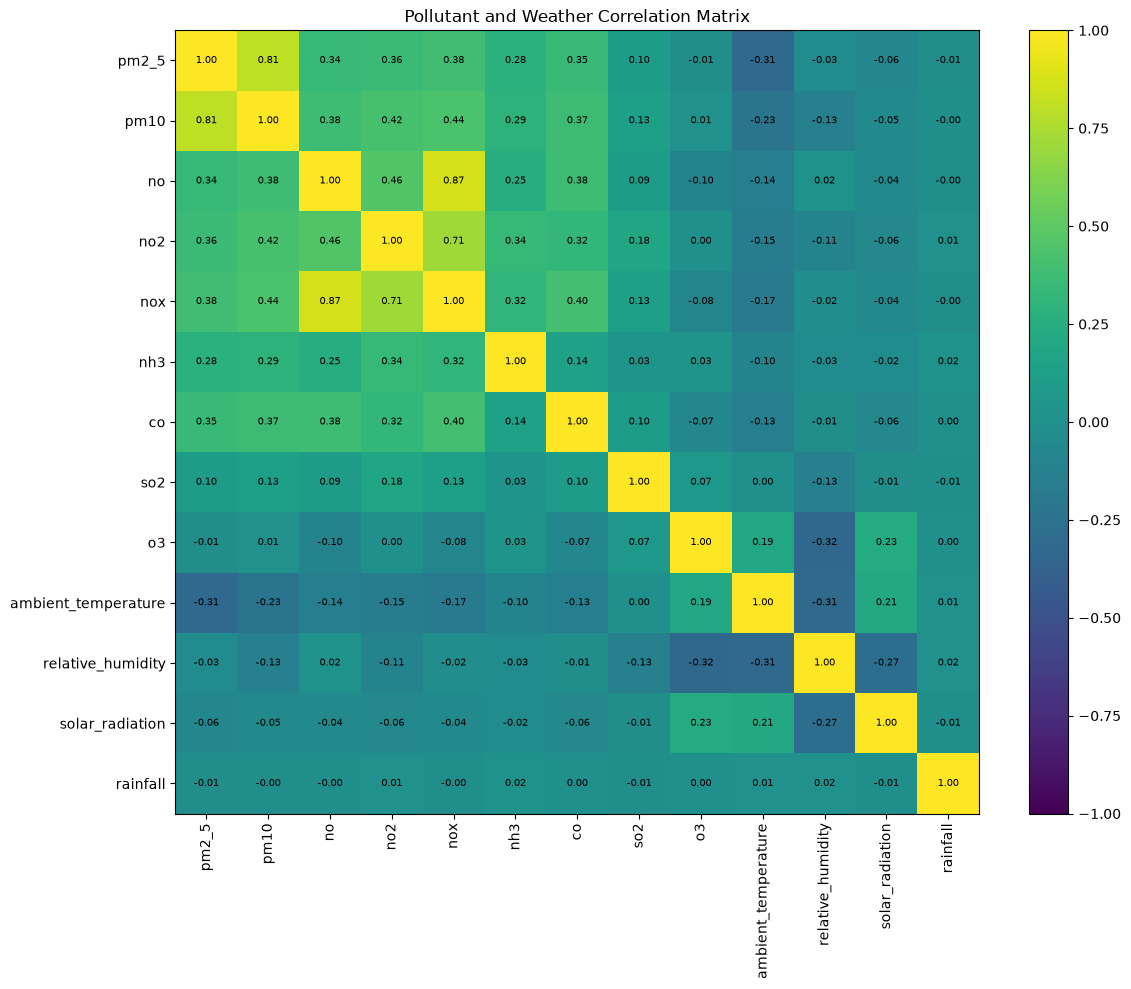

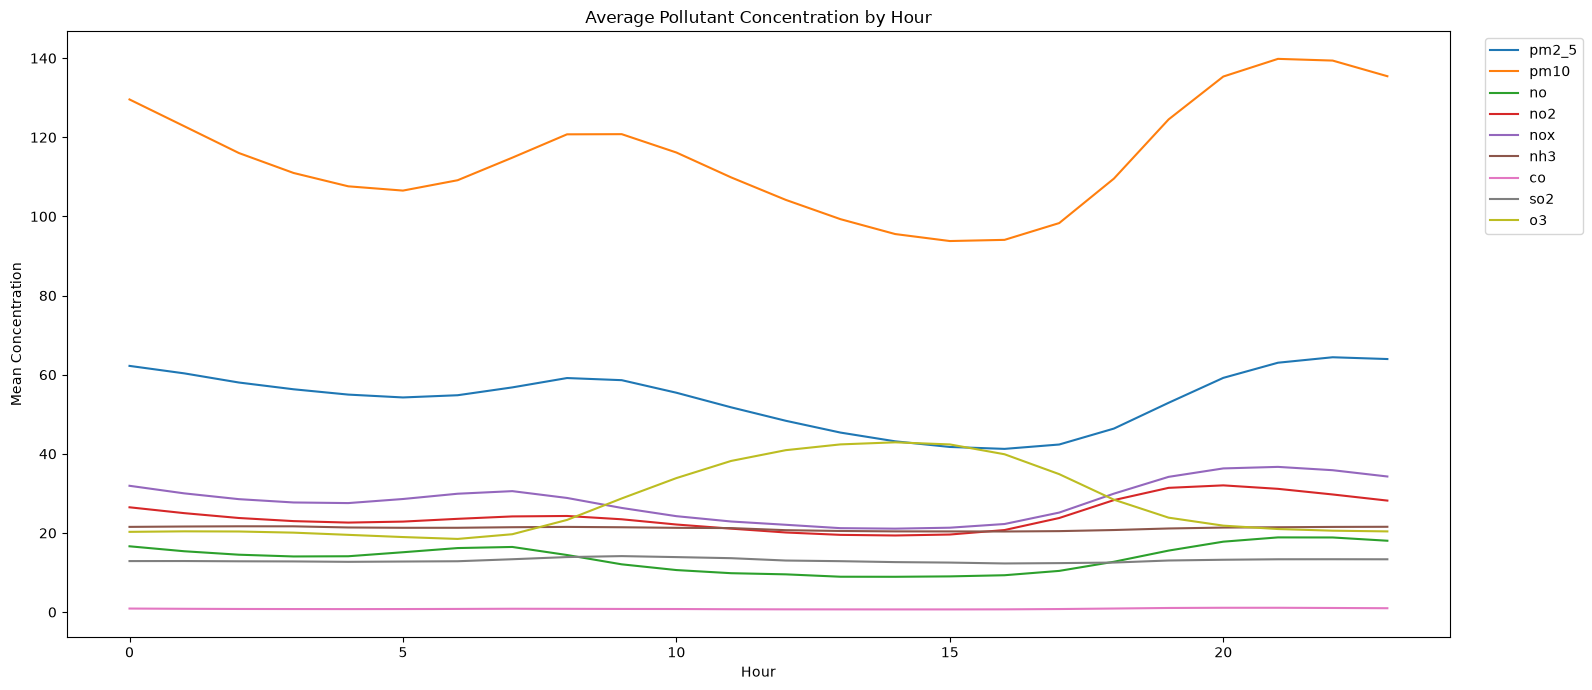

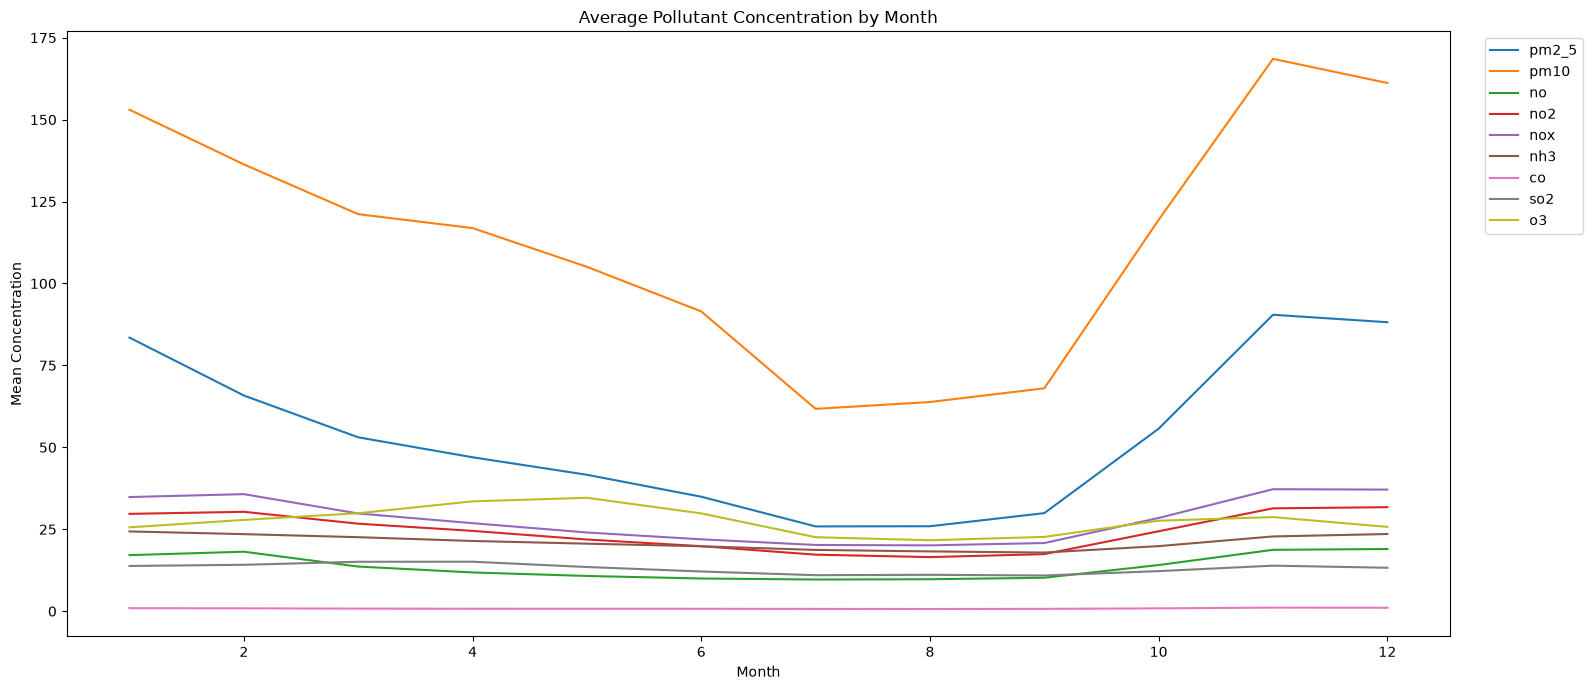

DAY-OF-WEEK PATTERN


,pm2_5,pm10,no,no2,nox,nh3,co,so2,o3
day_of_week,,,,,,,,,
0,53.7244,114.2264,13.6285,24.4541,28.2828,21.0593,0.8334,13.0712,27.8461
1,54.3051,116.2237,13.7733,24.5371,28.3926,21.1928,0.8380,13.0877,27.6908
2,54.2933,116.1322,13.8632,24.5918,28.4637,21.2353,0.8393,13.0715,27.5670
3,54.1179,115.4368,13.6460,24.5422,28.2518,21.2541,0.8357,13.0265,27.4861
4,53.5850,114.3137,13.4465,24.3876,28.0481,21.1691,0.8318,13.0052,27.5032
5,53.7880,114.2083,13.6057,24.4865,28.2641,21.1151,0.8351,13.0957,27.4806
6,53.5208,112.3955,13.3738,23.9576,27.7076,21.1553,0.8148,13.0391,27.8996


13929

In [6]:
correlation_columns = (
    available_pollutants
    + available_weather_columns
)

correlation_sample_size = min(
    500_000,
    len(df),
)

correlation_df = df[
    correlation_columns
].sample(
    n=correlation_sample_size,
    random_state=42,
)

correlation_matrix = (
    correlation_df
    .corr(
        method="pearson",
    )
)

print("POLLUTANT AND WEATHER CORRELATION")

display(
    correlation_matrix.round(3)
)

fig, ax = plt.subplots(
    figsize=(12, 10)
)

correlation_image = ax.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90,
)

ax.set_yticklabels(
    correlation_matrix.index,
)

for row_index in range(
    len(correlation_matrix.index)
):
    for column_index in range(
        len(correlation_matrix.columns)
    ):
        ax.text(
            column_index,
            row_index,
            f"{correlation_matrix.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

fig.colorbar(
    correlation_image,
    ax=ax,
)

ax.set_title(
    "Pollutant and Weather Correlation Matrix"
)

plt.tight_layout()
plt.show()

hourly_pattern = (
    df.groupby(
        "hour",
        observed=True,
    )[available_pollutants]
    .mean()
)

daily_pattern = (
    df.groupby(
        "day_of_week",
        observed=True,
    )[available_pollutants]
    .mean()
)

monthly_pattern = (
    df.groupby(
        "month",
        observed=True,
    )[available_pollutants]
    .mean()
)

fig, ax = plt.subplots(
    figsize=(16, 7)
)

hourly_pattern.plot(
    ax=ax,
)

ax.set_title(
    "Average Pollutant Concentration by Hour"
)

ax.set_xlabel("Hour")
ax.set_ylabel("Mean Concentration")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(
    figsize=(16, 7)
)

monthly_pattern.plot(
    ax=ax,
)

ax.set_title(
    "Average Pollutant Concentration by Month"
)

ax.set_xlabel("Month")
ax.set_ylabel("Mean Concentration")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

print("DAY-OF-WEEK PATTERN")

display(daily_pattern)

del correlation_df

gc.collect()

# 5. Sequence continuity and TFT/PatchTST forcasting

SEQUENCE READINESS ANALYSIS
Encoder length: 168 hours
Prediction length: 15 hours
Required sequence length: 183 hours

Total segments: 8,909
Valid segments: 2,937
Valid segment percentage: 32.97%

Estimated valid forecasting windows: 2,615,303
Stations with valid sequences: 66
Rows following time gaps: 8,843

SEGMENT LENGTH STATISTICS


,segment_length
count,"8,909.0000"
mean,384.9052
std,"1,003.2347"
min,1.0000
25%,17.0000
50%,69.0000
75%,308.0000
90%,938.2000
95%,"1,726.2000"
99%,"4,998.6800"


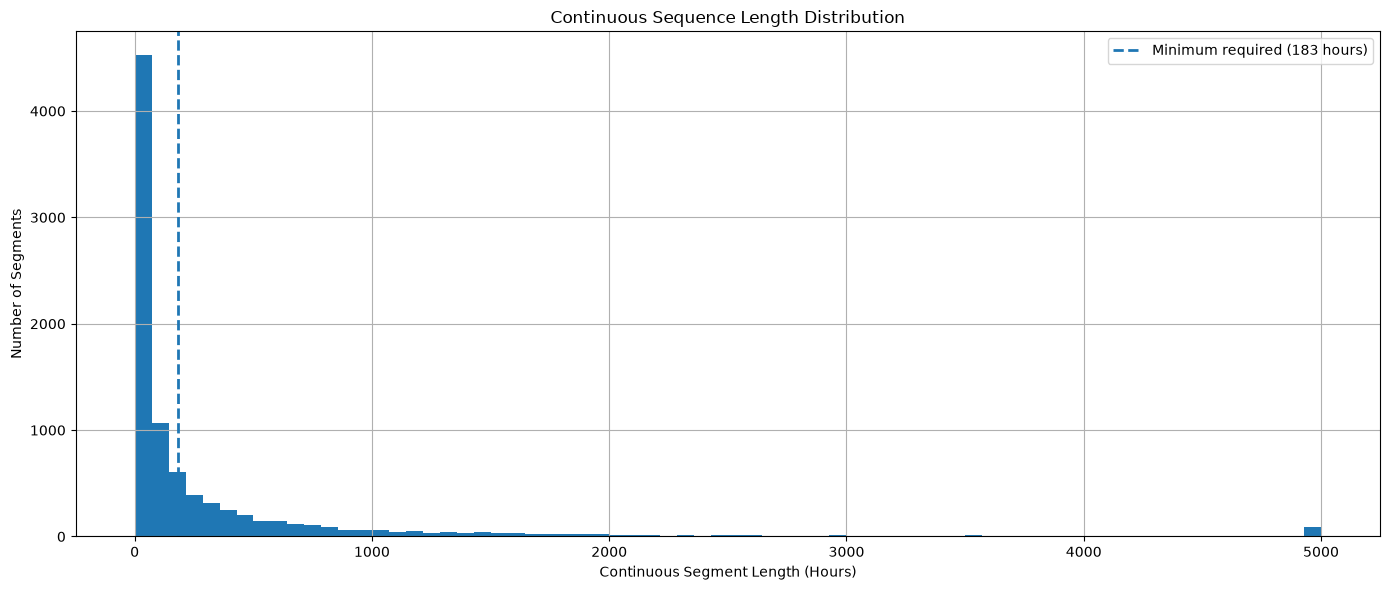

5980

In [9]:
# Sequence Continuity and Forecasting Readiness Analysis

segment_summary = (
    df.groupby(
        [
            "station_id",
            "sequence_segment_id",
        ],
        observed=True,
        sort=False,
    )
    .size()
    .rename("segment_length")
    .reset_index()
)

# Ensure segment length is numeric
segment_summary["segment_length"] = pd.to_numeric(
    segment_summary["segment_length"],
    errors="raise",
)

# Calculate valid forecasting windows
segment_summary["valid_forecast_windows"] = (
    segment_summary["segment_length"]
    - REQUIRED_SEQUENCE_LENGTH
    + 1
).clip(lower=0)

# Select segments long enough for:
# 168 encoder hours + 15 prediction hours
valid_segments = segment_summary[
    segment_summary["segment_length"]
    >= REQUIRED_SEQUENCE_LENGTH
].copy()

total_segments = len(segment_summary)

valid_segment_count = len(valid_segments)

total_valid_windows = int(
    segment_summary[
        "valid_forecast_windows"
    ].sum()
)

stations_with_valid_sequences = (
    valid_segments["station_id"]
    .nunique()
)

gap_rows = int(
    df["has_time_gap"].sum()
)

print("SEQUENCE READINESS ANALYSIS")

print(
    f"Encoder length: "
    f"{ENCODER_LENGTH} hours"
)

print(
    f"Prediction length: "
    f"{PREDICTION_LENGTH} hours"
)

print(
    f"Required sequence length: "
    f"{REQUIRED_SEQUENCE_LENGTH} hours"
)

print(
    f"\nTotal segments: "
    f"{total_segments:,}"
)

print(
    f"Valid segments: "
    f"{valid_segment_count:,}"
)

valid_segment_percentage = (
    valid_segment_count
    / total_segments
    * 100
    if total_segments > 0
    else 0.0
)

print(
    f"Valid segment percentage: "
    f"{valid_segment_percentage:,.2f}%"
)

print(
    f"\nEstimated valid forecasting windows: "
    f"{total_valid_windows:,}"
)

print(
    f"Stations with valid sequences: "
    f"{stations_with_valid_sequences:,}"
)

print(
    f"Rows following time gaps: "
    f"{gap_rows:,}"
)

print("\nSEGMENT LENGTH STATISTICS")

display(
    segment_summary[
        "segment_length"
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame()
)

fig, ax = plt.subplots(
    figsize=(14, 6)
)

segment_length_upper_limit = (
    segment_summary[
        "segment_length"
    ].quantile(0.99)
)

segment_summary[
    "segment_length"
].clip(
    upper=segment_length_upper_limit
).hist(
    bins=70,
    ax=ax,
)

ax.axvline(
    REQUIRED_SEQUENCE_LENGTH,
    linestyle="--",
    linewidth=2,
    label=(
        f"Minimum required "
        f"({REQUIRED_SEQUENCE_LENGTH} hours)"
    ),
)

ax.set_title(
    "Continuous Sequence Length Distribution"
)

ax.set_xlabel(
    "Continuous Segment Length (Hours)"
)

ax.set_ylabel(
    "Number of Segments"
)

ax.legend()

plt.tight_layout()
plt.show()

gc.collect()

# 6. Final model readiness report

In [10]:
target_missing_percent = (
    df[available_pollutants]
    .isna()
    .mean()
    .mul(100)
)

target_infinite_count = sum(
    int(
        np.isinf(
            df[col]
            .to_numpy(
                dtype=np.float64,
                na_value=np.nan,
            )
        ).sum()
    )
    for col in available_pollutants
)

duplicate_station_time_rows = int(
    df.duplicated(
        subset=[
            "station_id",
            "timestamp",
        ]
    ).sum()
)

time_order_valid = bool(
    df[
        [
            "station_id",
            "timestamp",
        ]
    ]
    .equals(
        df[
            [
                "station_id",
                "timestamp",
            ]
        ]
        .sort_values(
            [
                "station_id",
                "timestamp",
            ]
        )
        .reset_index(drop=True)
    )
)

readiness_checks = pd.Series(
    {
        "dataset_not_empty": not df.empty,
        "timestamp_complete": (
            df["timestamp"].notna().all()
        ),
        "station_id_complete": (
            df["station_id"].notna().all()
        ),
        "time_idx_complete": (
            df["time_idx"].notna().all()
        ),
        "no_duplicate_station_timestamp": (
            duplicate_station_time_rows == 0
        ),
        "time_order_valid": time_order_valid,
        "no_target_infinities": (
            target_infinite_count == 0
        ),
        "valid_sequence_segments_exist": (
            valid_segment_count > 0
        ),
        "valid_forecast_windows_exist": (
            total_valid_windows > 0
        ),
    },
    name="passed",
)

print("MODEL READINESS CHECKS")

display(
    readiness_checks.to_frame()
)

print("\nTARGET MISSING PERCENTAGE")

display(
    target_missing_percent
    .sort_values(
        ascending=False
    )
    .to_frame(
        "missing_percent"
    )
)

all_checks_passed = bool(
    readiness_checks.all()
)

print("\nFINAL EDA REPORT")

print(
    f"Rows: {len(df):,}"
)

print(
    f"Stations: "
    f"{df['station_id'].nunique():,}"
)

print(
    f"Pollutant targets: "
    f"{len(available_pollutants)}"
)

print(
    f"Valid continuous segments: "
    f"{valid_segment_count:,}"
)

print(
    f"Estimated forecasting windows: "
    f"{total_valid_windows:,}"
)

print(
    "\nTFT readiness: "
    f"{'READY' if all_checks_passed else 'REVIEW REQUIRED'}"
)

print(
    "PatchTST readiness: "
    f"{'READY' if all_checks_passed else 'REVIEW REQUIRED'}"
)

if not all_checks_passed:
    failed_checks = (
        readiness_checks[
            ~readiness_checks
        ]
        .index
        .tolist()
    )

    print(
        "\nFailed checks:"
    )

    for check in failed_checks:
        print(f"- {check}")

print(
    "\nEDA completed successfully."
)

MODEL READINESS CHECKS


,passed
dataset_not_empty,True
timestamp_complete,True
station_id_complete,True
time_idx_complete,True
no_duplicate_station_timestamp,True
time_order_valid,True
no_target_infinities,True
valid_sequence_segments_exist,True
valid_forecast_windows_exist,True



TARGET MISSING PERCENTAGE


,missing_percent
pm2_5,0.0000
pm10,0.0000
no,0.0000
no2,0.0000
nox,0.0000
nh3,0.0000
co,0.0000
so2,0.0000
o3,0.0000



FINAL EDA REPORT
Rows: 3,429,120
Stations: 66
Pollutant targets: 9
Valid continuous segments: 2,937
Estimated forecasting windows: 2,615,303

TFT readiness: READY
PatchTST readiness: READY

EDA completed successfully.
